# Improvements over Baseline — Grupo Bimbo

Three targeted improvements on top of the XGBoost baseline:

- **Improvement 1:** Return-rate features (`hist_return_rate` + `canal_return_rate`)
- **Improvement 2:** Spatial cluster features (`geo_cluster`, `dist_to_hub_km`, `lat_zone`)
- **Improvement 3:** Product-channel interaction features (`weight_g`, `units_per_pack`, `weight_per_unit`, `pc_median_demand`, `pc_std_demand`)

Additional model improvements:
- Rolling lag extended to 3 weeks (`demand_roll3`)
- NaN imputation with per-feature medians instead of flat `-1`
- Early stopping to avoid overfitting with the larger feature set
- `min_child_weight=5` to be more conservative on sparse zero-demand rows

## 0. Setup

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import xgboost as xgb
from sklearn.metrics import mean_squared_log_error

PROJECT_ROOT = Path("..").resolve()
INTERIM_DIR  = PROJECT_ROOT / "data" / "interim"
RAW_DIR      = PROJECT_ROOT / "data" / "raw" / "csv"

BASELINE_RMSLE = 0.4646

print("Ready.")

Ready.


## 1. Load Data

In [3]:
train_full = pd.read_csv(
    RAW_DIR / "train.csv",
    dtype={
        "Semana": "int8", "Agencia_ID": "int32", "Canal_ID": "int8",
        "Ruta_SAK": "int32", "Cliente_ID": "int32", "Producto_ID": "int32",
        "Venta_uni_hoy": "int32", "Dev_uni_proxima": "int32",
        "Demanda_uni_equil": "int32"
    },
    usecols=[
        "Semana", "Agencia_ID", "Canal_ID", "Ruta_SAK", "Cliente_ID",
        "Producto_ID", "Venta_uni_hoy", "Dev_uni_proxima", "Demanda_uni_equil"
    ]
)

np.random.seed(42)
sample_agencies = np.random.choice(
    train_full["Agencia_ID"].unique(), size=50, replace=False
)
train = train_full[train_full["Agencia_ID"].isin(sample_agencies)].copy()
del train_full

print(f"Rows: {len(train):,}")
print(f"Weeks: {sorted(train['Semana'].unique())}")

Rows: 8,820,263
Weeks: [np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9)]


## 2. Feature Engineering

All functions are written to be **leakage-free**: every aggregation uses only data strictly prior to the current week (via `.shift(1)` before any cumsum or rolling window).

In [ ]:
def build_lag_features(df):
    """
    Compute lag-1, lag-2, lag-3 demand and rolling means
    per (Producto_ID, Agencia_ID, Cliente_ID).
    df must be sorted by Semana before calling.
    """
    key = ["Producto_ID", "Agencia_ID", "Cliente_ID"]
    df = df.sort_values(["Semana"] + key).copy()

    for lag in [1, 2, 3]:
        df[f"demand_lag{lag}"] = (
            df.groupby(key)["Demanda_uni_equil"].shift(lag)
        )

    df["demand_roll2"] = (
        df.groupby(key)["Demanda_uni_equil"]
        .transform(lambda x: x.shift(1).rolling(2, min_periods=1).mean())
    )

    df["demand_roll3"] = (
        df.groupby(key)["Demanda_uni_equil"]
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )

    return df

In [ ]:
# --- Improvement 1: Return-rate features ---
def add_return_rate_features(df):
    """
    Two leakage-free return-rate signals:

    1. hist_return_rate — cumulative return rate per (product, agency, channel)
       using only weeks strictly before the current one.

    2. canal_return_rate — global return rate per (channel, week),
       also shifted to avoid leakage. Acts as a fallback for sparse triplets.

    Why not use -1 as fill? hist_return_rate is bounded [0, 1], so -1 sends
    a nonsensical signal to the tree. We use the channel-level rate instead.
    """
    key = ["Producto_ID", "Agencia_ID", "Canal_ID"]
    df = df.sort_values(["Semana"] + key).copy()

    df["cum_dev"] = df.groupby(key)["Dev_uni_proxima"].transform(
        lambda x: x.shift(1).expanding().sum()
    )
    df["cum_venta"] = df.groupby(key)["Venta_uni_hoy"].transform(
        lambda x: x.shift(1).expanding().sum()
    )
    df["hist_return_rate"] = df["cum_dev"] / (df["cum_venta"] + 1)

    canal_rr = (
        df.sort_values("Semana")
        .groupby(["Canal_ID", "Semana"], observed=True)
        .apply(
            lambda g: g["Dev_uni_proxima"].sum() / (g["Venta_uni_hoy"].sum() + 1),
            include_groups=False
        )
        .reset_index(name="canal_return_rate")
    )
    canal_rr["Semana"] = canal_rr["Semana"] + 1
    df = df.merge(canal_rr, on=["Canal_ID", "Semana"], how="left")

    df["hist_return_rate"] = df["hist_return_rate"].fillna(
        df["canal_return_rate"]
    )

    df.drop(columns=["cum_dev", "cum_venta"], inplace=True)
    return df

In [6]:
# --- Improvement 2: Spatial cluster features ---
def add_spatial_features(df, interim_dir):
    """
    Merge pre-computed spatial features from the geolocation pipeline.
    Columns used: geo_cluster, dist_to_hub_km, lat_zone.

    lat_zone (south / central / north) is encoded as an integer so XGBoost
    can split on it as a numeric feature.
    """
    geo = pd.read_parquet(
        interim_dir / "agency_geolocation_features.parquet",
        columns=["Agencia_ID", "geo_cluster", "dist_to_hub_km", "lat_zone"]
    )

    # Encode lat_zone as integer: south=0, central=1, north=2
    zone_map = {"south": 0, "central": 1, "north": 2}
    geo["lat_zone_enc"] = geo["lat_zone"].map(zone_map).fillna(1).astype(int)
    geo.drop(columns=["lat_zone"], inplace=True)

    df = df.merge(geo, on="Agencia_ID", how="left")
    return df

In [ ]:
# --- Improvement 3: Product-channel interaction features ---
def add_product_channel_features(df, raw_dir):
    """
    Parse weight and unit count from NombreProducto, then compute
    product-channel median and std demand from training data only.

    weight_per_unit_g is a freshness proxy: heavy single-unit items
    (bread loaves) spoil faster than small multi-unit packs.
    """
    products = pd.read_csv(
        raw_dir / "producto_tabla.csv",
        usecols=["Producto_ID", "NombreProducto"]
    )

    def extract_weight_g(name):
        m = re.search(r"(\d+(?:\.\d+)?)\s*[Gg]", str(name))
        return float(m.group(1)) if m else np.nan

    def extract_units(name):
        m = re.search(r"(\d+)\s*[Pp]z", str(name))
        return float(m.group(1)) if m else 1.0

    products["weight_g"]          = products["NombreProducto"].apply(extract_weight_g)
    products["units_per_pack"]     = products["NombreProducto"].apply(extract_units)
    products["weight_per_unit_g"]  = products["weight_g"] / products["units_per_pack"]

    df = df.merge(
        products[["Producto_ID", "weight_g", "units_per_pack", "weight_per_unit_g"]],
        on="Producto_ID", how="left"
    )

    train_only = df[df["Semana"] <= 7]
    pc_stats = (
        train_only
        .groupby(["Producto_ID", "Canal_ID"])["Demanda_uni_equil"]
        .agg(["median", "std"])
        .reset_index()
        .rename(columns={"median": "pc_median_demand", "std": "pc_std_demand"})
    )
    df = df.merge(pc_stats, on=["Producto_ID", "Canal_ID"], how="left")
    return df

In [ ]:
train = build_lag_features(train)
train = add_return_rate_features(train)
train = add_spatial_features(train, INTERIM_DIR)
train = add_product_channel_features(train, RAW_DIR)

train_model = train.dropna(subset=["demand_lag1", "demand_lag2"])

print(f"Rows ready: {len(train_model):,}")
print(f"Columns: {len(train_model.columns)}")
print("\nNew features added:")
new_cols = [
    "demand_roll3", "hist_return_rate", "canal_return_rate",
    "geo_cluster", "dist_to_hub_km", "lat_zone_enc",
    "weight_g", "units_per_pack", "weight_per_unit_g",
    "pc_median_demand", "pc_std_demand"
]
print(train_model[new_cols].describe().T[["count", "mean", "min", "max"]])

Rows ready: 3,827,882
Columns: 24

New features added:
                       count        mean       min          max
demand_roll3       3827882.0    9.497185       0.0       4228.0
hist_return_rate   3827882.0    0.018681       0.0        425.0
canal_return_rate  3825024.0    0.015085  0.002631     0.044698
geo_cluster        3827882.0    3.643067       0.0          7.0
dist_to_hub_km     3827882.0  424.799426  0.442923  2058.256565
lat_zone_enc       3827882.0    0.943002       0.0          2.0
weight_g           3796121.0  199.077588       5.0       5400.0
units_per_pack     3827882.0    1.003724       1.0         25.0
weight_per_unit_g  3796121.0  199.070077       2.0       5400.0
pc_median_demand   3827681.0     6.45511       0.0       2760.0
pc_std_demand      3827670.0    9.060912       0.0  1491.242615


## 3. Train Improved Model

In [ ]:
FEATURES_IMPROVED = [
    "Semana", "Agencia_ID", "Canal_ID", "Ruta_SAK",
    "Cliente_ID", "Producto_ID",
    "demand_lag1", "demand_lag2", "demand_lag3",
    "demand_roll2",
    "demand_roll3",
    "hist_return_rate",
    "canal_return_rate",
    "geo_cluster",
    "dist_to_hub_km",
    "lat_zone_enc",
    "weight_g",
    "units_per_pack",
    "weight_per_unit_g",
    "pc_median_demand",
    "pc_std_demand",
]

TARGET = "Demanda_uni_equil"

train_data = train_model[train_model["Semana"] <= 7]
val_data   = train_model[train_model["Semana"] >= 8]

fill_values = train_data[FEATURES_IMPROVED].median()

X_train = train_data[FEATURES_IMPROVED].fillna(fill_values)
y_train = np.log1p(train_data[TARGET])
X_val   = val_data[FEATURES_IMPROVED].fillna(fill_values)
y_val   = val_data[TARGET]

print(f"Train: {len(X_train):,} rows (weeks 3-7)")
print(f"Val:   {len(X_val):,} rows (weeks 8-9)")
print(f"Features: {len(FEATURES_IMPROVED)}")

Train: 2,155,812 rows (weeks 3-7)
Val:   1,672,070 rows (weeks 8-9)
Features: 21


In [ ]:
model_improved = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric="rmse",
)

model_improved.fit(
    X_train, y_train,
    eval_set=[(X_val, np.log1p(y_val))],
    verbose=100,
)

preds_improved = np.expm1(model_improved.predict(X_val)).clip(0)
rmsle_improved = np.sqrt(mean_squared_log_error(y_val, preds_improved))

print(f"\nBaseline RMSLE:  {BASELINE_RMSLE:.4f}")
print(f"Improved RMSLE:  {rmsle_improved:.4f}")
print(f"Improvement:     {BASELINE_RMSLE - rmsle_improved:.4f}")
print(f"Best iteration:  {model_improved.best_iteration}")

[0]	validation_0-rmse:0.85207
[100]	validation_0-rmse:0.46262
[200]	validation_0-rmse:0.46210
[243]	validation_0-rmse:0.46216

Baseline RMSLE:  0.4646
Improved RMSLE:  0.4621
Improvement:     0.0025
Best iteration:  213


## 4. Feature Importance — Baseline vs Improved

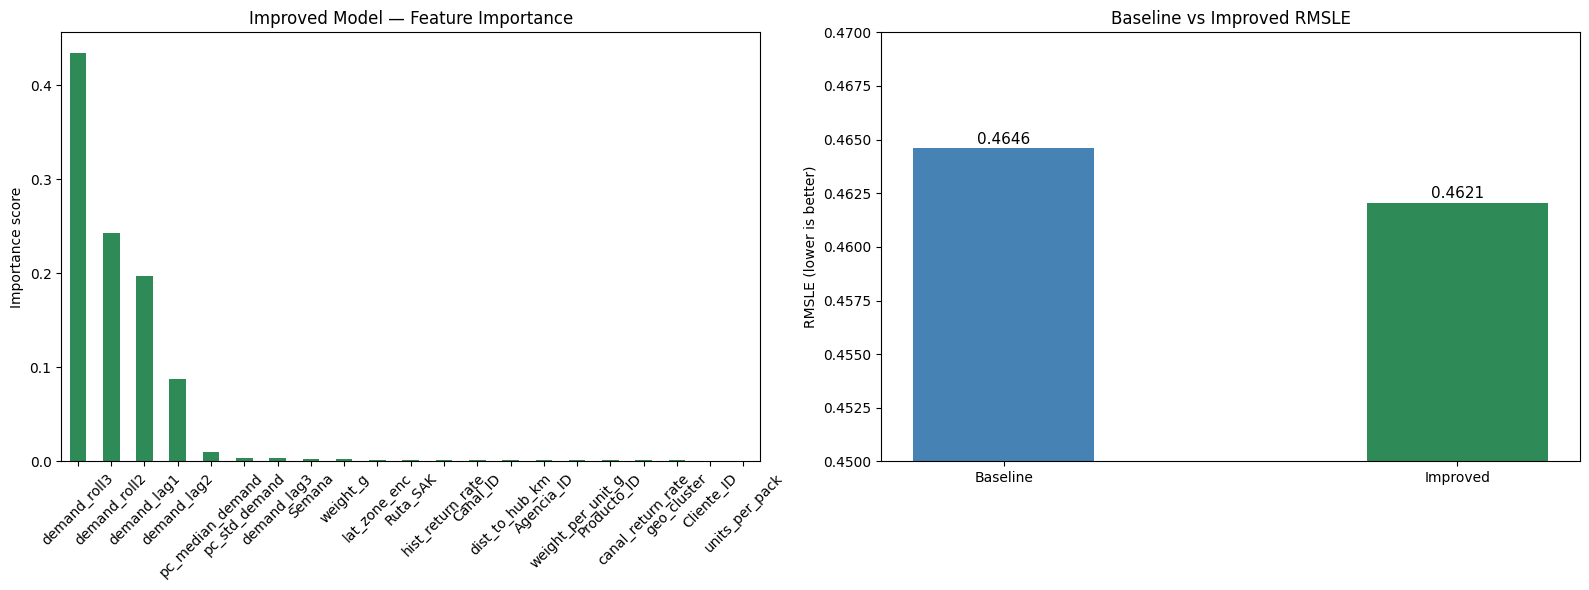


Top 10 features:
demand_roll3        0.434255
demand_roll2        0.242608
demand_lag1         0.196835
demand_lag2         0.087425
pc_median_demand    0.010288
pc_std_demand       0.004196
demand_lag3         0.003375
Semana              0.002505
weight_g            0.002132
lat_zone_enc        0.002058


In [12]:
FEATURES_BASELINE = [
    "Semana", "Agencia_ID", "Canal_ID", "Ruta_SAK",
    "Cliente_ID", "Producto_ID",
    "demand_lag1", "demand_lag2", "demand_lag3", "demand_roll2",
]

model_baseline = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    objective="reg:squarederror", random_state=42, n_jobs=-1,
)
model_baseline.fit(
    train_data[FEATURES_BASELINE],
    y_train,
    verbose=False
)

imp_improved = (
    pd.Series(model_improved.feature_importances_, index=FEATURES_IMPROVED)
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: improved model feature importance
imp_improved.plot(kind="bar", ax=axes[0], color="seagreen")
axes[0].set_title("Improved Model — Feature Importance")
axes[0].set_ylabel("Importance score")
axes[0].tick_params(axis="x", rotation=45)

# Right: RMSLE comparison
bars = axes[1].bar(
    ["Baseline", "Improved"],
    [BASELINE_RMSLE, rmsle_improved],
    color=["steelblue", "seagreen"],
    width=0.4
)
axes[1].set_ylim(0.45, 0.47)
axes[1].set_ylabel("RMSLE (lower is better)")
axes[1].set_title("Baseline vs Improved RMSLE")
for bar, val in zip(bars, [BASELINE_RMSLE, rmsle_improved]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0002,
        f"{val:.4f}", ha="center", fontsize=11
    )

plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(imp_improved.head(10).to_string())

## 5. Save Model

In [14]:
import pickle

models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(exist_ok=True)

model_bundle = {
    "model": model_improved,
    "features": FEATURES_IMPROVED,
    "fill_values": fill_values,
}

with open(models_dir / "bimbo_improved.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

print("Model saved to models/bimbo_improved.pkl")
print(f"Features saved: {FEATURES_IMPROVED}")

Model saved to models/bimbo_improved.pkl
Features saved: ['Semana', 'Agencia_ID', 'Canal_ID', 'Ruta_SAK', 'Cliente_ID', 'Producto_ID', 'demand_lag1', 'demand_lag2', 'demand_lag3', 'demand_roll2', 'demand_roll3', 'hist_return_rate', 'canal_return_rate', 'geo_cluster', 'dist_to_hub_km', 'lat_zone_enc', 'weight_g', 'units_per_pack', 'weight_per_unit_g', 'pc_median_demand', 'pc_std_demand']
